# Zig-Zag Motion: Acceleration Settings Impact

This notebook explores how different acceleration and jerk settings affect zig-zag motion patterns.

Zig-zag patterns are particularly challenging for CNC machines because they involve:
- Rapid direction changes
- Frequent acceleration/deceleration
- Corner blending decisions
- Potential for vibration and resonance

We'll test multiple configurations and visualize the trade-offs.

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import sys
import os

sys.path.insert(0, os.path.abspath('../python_bindings/build'))
import pygcode
import pyexport

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

## Generate Zig-Zag G-Code

Create a zig-zag pattern with configurable parameters.

In [42]:
def generate_zigzag_gcode(width=100, height=50, num_zigzags=5, feedrate=3000):
    """Generate G-code for a zig-zag pattern.
    
    Args:
        width: Total width of pattern (mm)
        height: Height of each zig-zag (mm)
        num_zigzags: Number of complete zig-zags
        feedrate: Feed rate (mm/min)
    """
    segment_width = width / num_zigzags
    
    gcode = f"""
G21 ; millimeters
G90 ; absolute
F{feedrate}
G64 P3.0 ; Path blending with 3.0mm tolerance (Large P value to allow visible corner rounding differences)

G0 X0 Y0 ; Start position
"""
    
    x = 0
    y = 0
    going_up = True
    
    for i in range(num_zigzags * 2):
        x += segment_width / 2
        y = height if going_up else 0
        gcode += f"G1 X{x:.3f} Y{y:.3f}\n"
        going_up = not going_up
    
    return gcode

# Generate a more challenging pattern: more zigzags, tighter corners
preview_gcode = generate_zigzag_gcode(width=100, height=50, num_zigzags=10, feedrate=3000)
print("Generated G-code preview:")
print(preview_gcode)

Generated G-code preview:

G21 ; millimeters
G90 ; absolute
F3000
G64 P3.0 ; Path blending with 3.0mm tolerance (Large P value to allow visible corner rounding differences)

G0 X0 Y0 ; Start position
G1 X5.000 Y50.000
G1 X10.000 Y0.000
G1 X15.000 Y50.000
G1 X20.000 Y0.000
G1 X25.000 Y50.000
G1 X30.000 Y0.000
G1 X35.000 Y50.000
G1 X40.000 Y0.000
G1 X45.000 Y50.000
G1 X50.000 Y0.000
G1 X55.000 Y50.000
G1 X60.000 Y0.000
G1 X65.000 Y50.000
G1 X70.000 Y0.000
G1 X75.000 Y50.000
G1 X80.000 Y0.000
G1 X85.000 Y50.000
G1 X90.000 Y0.000
G1 X95.000 Y50.000
G1 X100.000 Y0.000



## Test Different Acceleration Settings

We'll test the same zig-zag pattern with different acceleration and jerk settings.

In [43]:
# Define test configurations
configs = [
    {"name": "Low Accel, Low Jerk", "accel": 500, "jerk": 2000, "color": "blue"},
    {"name": "Medium Accel, Medium Jerk", "accel": 1000, "jerk": 5000, "color": "green"},
    {"name": "High Accel, Medium Jerk", "accel": 2000, "jerk": 5000, "color": "orange"},
    {"name": "High Accel, High Jerk", "accel": 2000, "jerk": 10000, "color": "red"},
    {"name": "Very High Accel, Very High Jerk", "accel": 5000, "jerk": 20000, "color": "purple"},
]

# Feed rates to test
feed_rates = [1000, 2000, 3000, 5000]  # mm/min

print(f"Testing {len(configs)} acceleration configurations")
print(f"Testing {len(feed_rates)} feed rates")
print(f"Total test cases: {len(configs) * len(feed_rates)}")

Testing 5 acceleration configurations
Testing 4 feed rates
Total test cases: 20


In [44]:
def process_zigzag(gcode_str, max_accel, max_jerk, max_vel=5000):
    """Process zig-zag G-code with specified limits."""
    
    parser = pygcode.Parser()
    parser.configure(linux_cnc=True)
    parser.parse_string(gcode_str)
    
    interp = pygcode.Interpreter()
    interp.configure(max_vel=max_vel, max_accel=max_accel, max_jerk=max_jerk)
    interp.set_position({"X": 0, "Y": 0, "Z": 0})
    
    interp.load_blocks(parser)
    interp.run()
    
    traj_gen = pygcode.TrajectoryGenerator()
    # High resolution sampling (0.5ms) to capture fine details
    traj_gen.configure(time_step=0.0005, use_s_curve=True, enable_jerk=True, max_jerk=max_jerk)
    traj_gen.generate(interp)
    
    return traj_gen.get_trajectory_array(), traj_gen.duration()

# Process with more zigzags to make differences visible
feed_rate = 3000  # mm/min
gcode = generate_zigzag_gcode(width=100, height=50, num_zigzags=10, feedrate=feed_rate)

results = []
for config in configs:
    print(f"Processing: {config['name']}...")
    trajectory, duration = process_zigzag(gcode, config['accel'], config['jerk'])
    
    results.append({
        **config,
        'trajectory': trajectory,
        'duration': duration,
        'feedrate': feed_rate
    })
    
    print(f"  Duration: {duration:.3f}s")

print("\nProcessing complete!")

Processing: Low Accel, Low Jerk...
  Duration: 20.100s
Processing: Medium Accel, Medium Jerk...
  Duration: 20.100s
Processing: High Accel, Medium Jerk...
  Duration: 20.100s
Processing: High Accel, High Jerk...
  Duration: 20.100s
Processing: Very High Accel, Very High Jerk...
  Duration: 20.100s

Processing complete!


## Visualization 1: Path Comparison

Compare the actual paths taken with different acceleration settings.

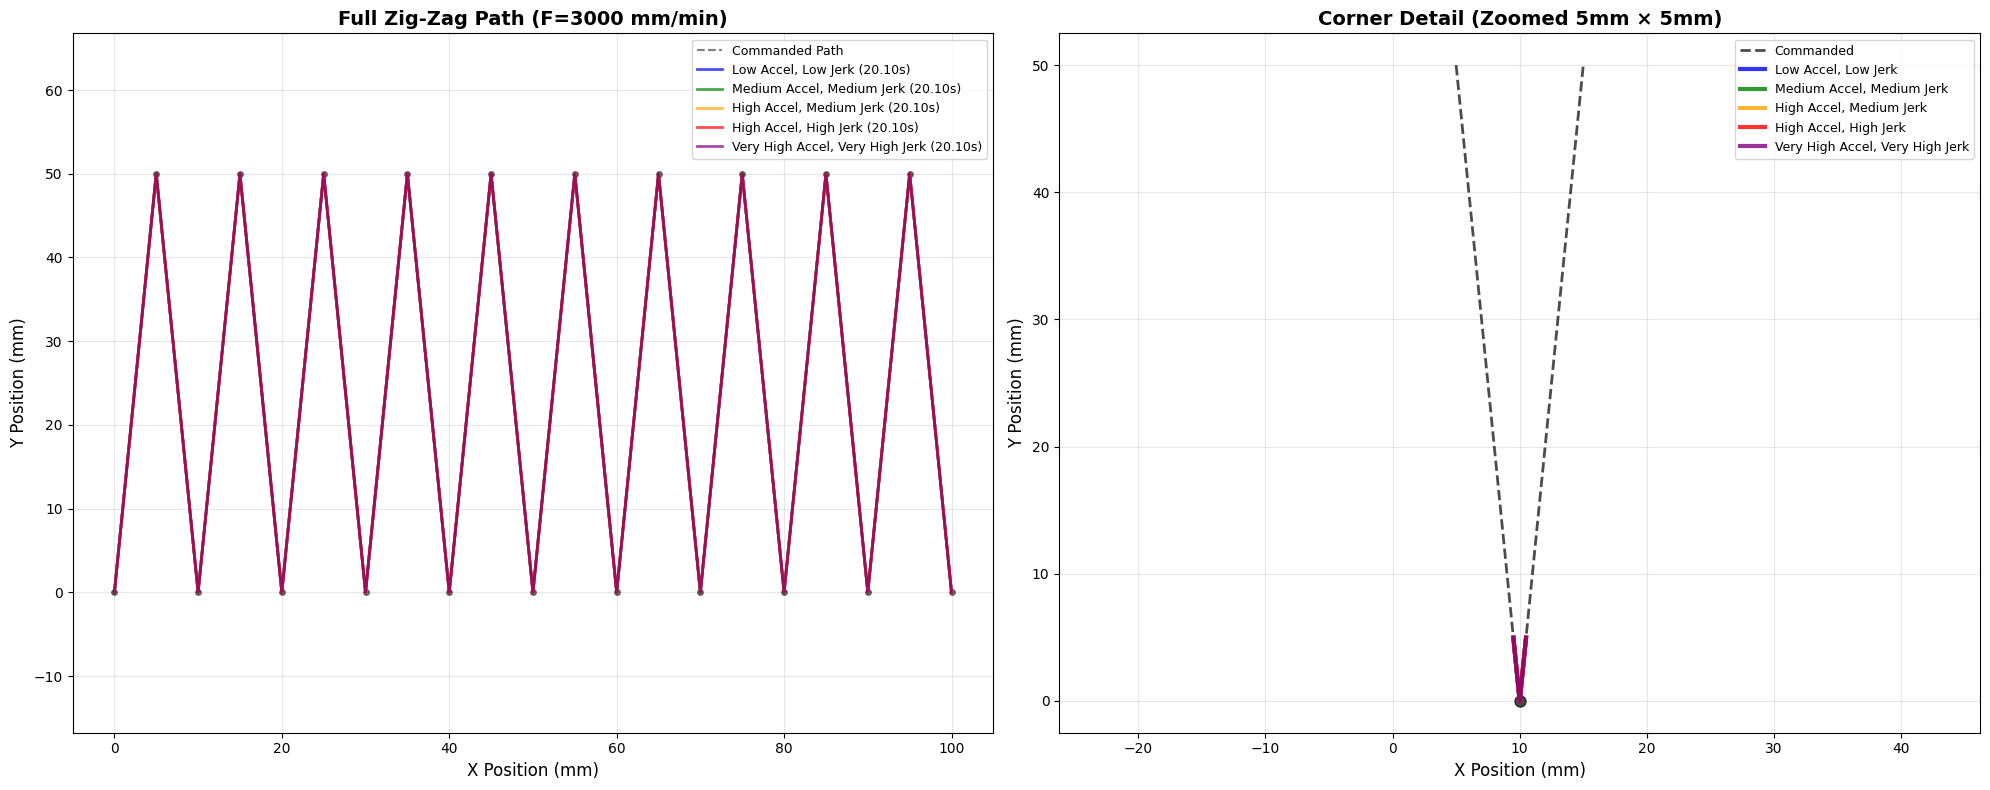

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left plot: Full view
ax = axes[0]

# Plot commanded path
gcode_lines = gcode.split('\n')
cmd_x, cmd_y = [0], [0]
for line in gcode_lines:
    if line.startswith('G1'):
        parts = line.split()
        x = next((float(p[1:]) for p in parts if p.startswith('X')), cmd_x[-1])
        y = next((float(p[1:]) for p in parts if p.startswith('Y')), cmd_y[-1])
        cmd_x.append(x)
        cmd_y.append(y)

ax.plot(cmd_x, cmd_y, 'k--', linewidth=1.5, label='Commanded Path', alpha=0.5)
ax.plot(cmd_x, cmd_y, 'ko', markersize=4, alpha=0.5)

# Plot each result
for result in results:
    traj = result['trajectory']
    x = traj[:, 1]
    y = traj[:, 2]
    
    ax.plot(x, y, color=result['color'], linewidth=2, 
            label=f"{result['name']} ({result['duration']:.2f}s)", alpha=0.7)

ax.set_xlabel('X Position (mm)', fontsize=12)
ax.set_ylabel('Y Position (mm)', fontsize=12)
ax.set_title(f'Full Zig-Zag Path (F={feed_rate} mm/min)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.axis('equal')

# Right plot: Zoomed view of corner
ax = axes[1]

# Plot commanded path corners
corner_idx = 2  # Pick the second corner to zoom in
if corner_idx < len(cmd_x):
    corner_x, corner_y = cmd_x[corner_idx], cmd_y[corner_idx]
    zoom_range = 5  # mm
    
    # Plot commanded corner
    ax.plot([cmd_x[corner_idx-1], cmd_x[corner_idx], cmd_x[corner_idx+1]], 
            [cmd_y[corner_idx-1], cmd_y[corner_idx], cmd_y[corner_idx+1]], 
            'k--', linewidth=2, label='Commanded', alpha=0.7)
    ax.plot(corner_x, corner_y, 'ko', markersize=8, alpha=0.7)
    
    # Plot actual trajectories near corner
    for result in results:
        traj = result['trajectory']
        x = traj[:, 1]
        y = traj[:, 2]
        
        # Find points near corner
        mask = (np.abs(x - corner_x) < zoom_range) & (np.abs(y - corner_y) < zoom_range)
        ax.plot(x[mask], y[mask], color=result['color'], linewidth=3, 
                label=result['name'], alpha=0.8)
    
    ax.set_xlim(corner_x - zoom_range, corner_x + zoom_range)
    ax.set_ylim(corner_y - zoom_range, corner_y + zoom_range)
    ax.set_xlabel('X Position (mm)', fontsize=12)
    ax.set_ylabel('Y Position (mm)', fontsize=12)
    ax.set_title(f'Corner Detail (Zoomed {zoom_range}mm × {zoom_range}mm)', 
                 fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axis('equal')

plt.tight_layout()
plt.savefig('zigzag_path_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualization 2: Velocity and Acceleration Profiles

Examine how velocity and acceleration change throughout the zig-zag pattern.

/home/uli/.local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1309: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/home/uli/.local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1310: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/home/uli/.local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1311: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/home/uli/.local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1317: RuntimeWarning: invalid value encountered in multiply
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] \
/home/uli/.local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1318: RuntimeWarning: invalid value encountered in multiply
  + c * f[tuple(slice4)]
/home/uli/.local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1327: RuntimeWarning: invalid value 

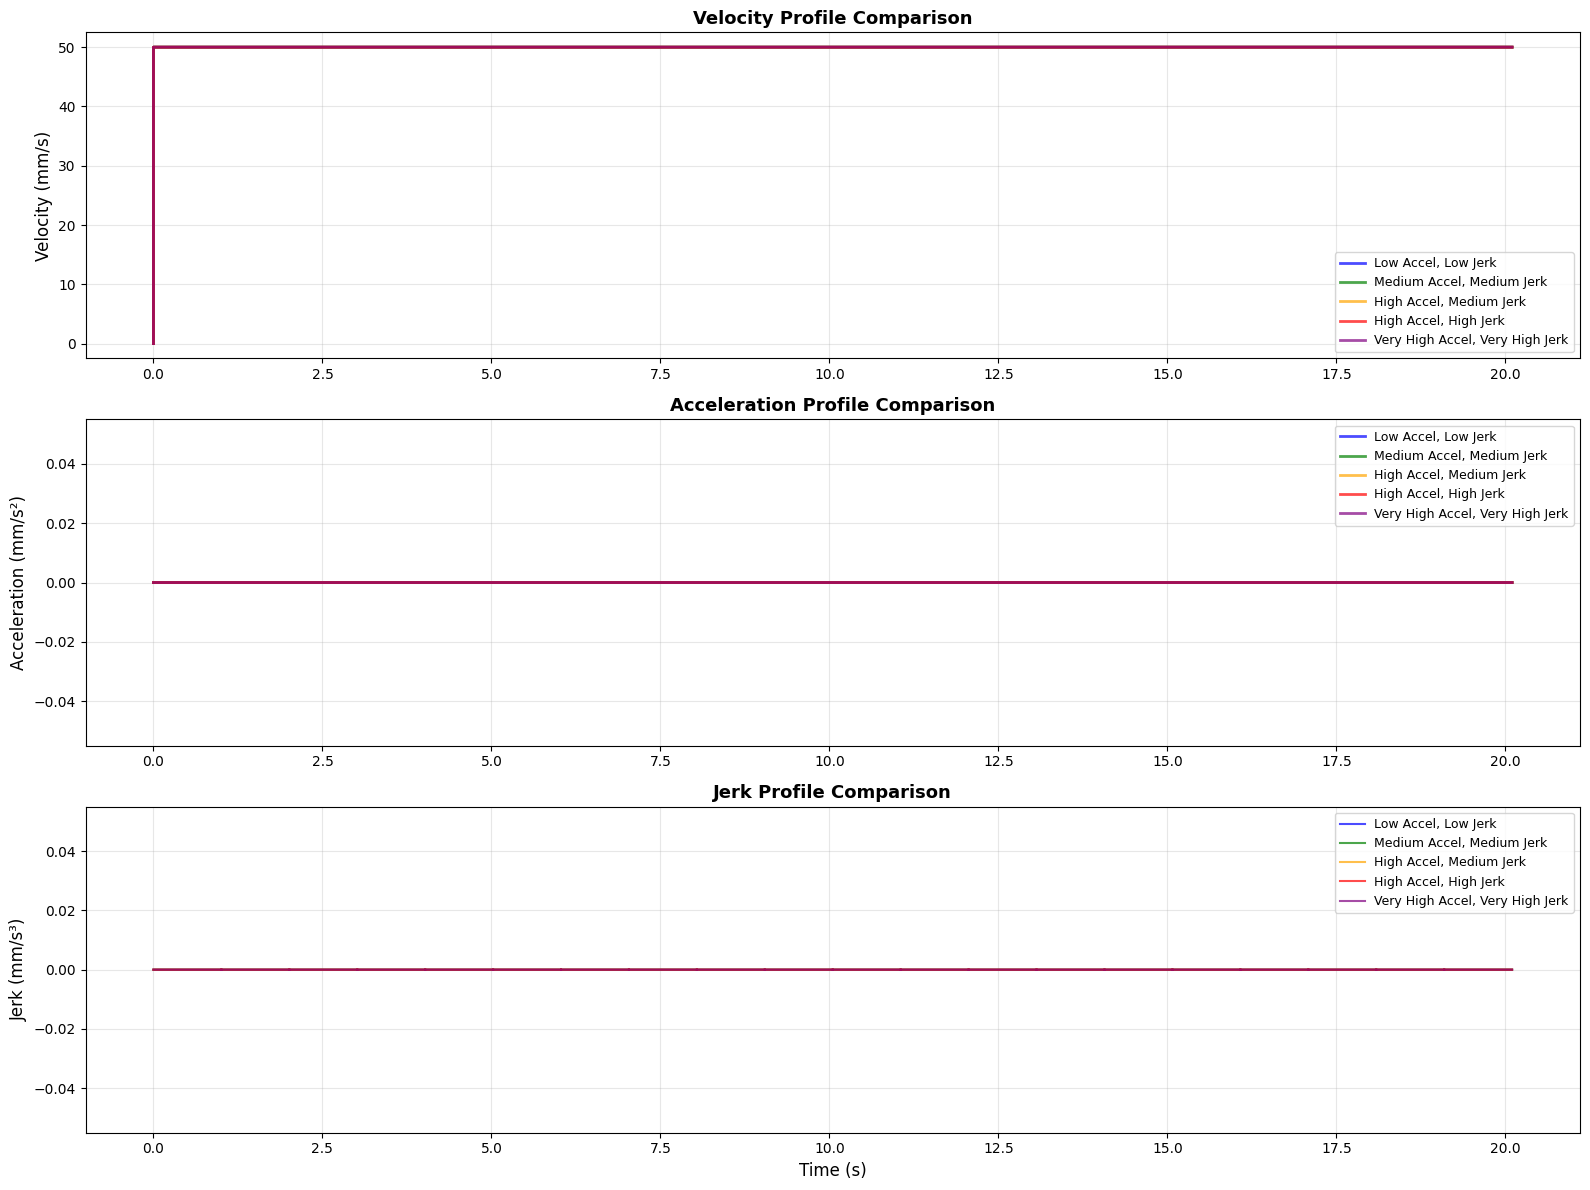

In [46]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for result in results:
    traj = result['trajectory']
    time = traj[:, 0]
    vx, vy = traj[:, 4], traj[:, 5]
    ax, ay = traj[:, 7], traj[:, 8]
    
    v_mag = np.sqrt(vx**2 + vy**2)
    a_mag = np.sqrt(ax**2 + ay**2)
    
    # Calculate jerk numerically
    jerk_x = np.gradient(ax, time)
    jerk_y = np.gradient(ay, time)
    jerk_mag = np.sqrt(jerk_x**2 + jerk_y**2)
    
    # Velocity
    axes[0].plot(time, v_mag, color=result['color'], linewidth=2, 
                 label=result['name'], alpha=0.7)
    
    # Acceleration
    axes[1].plot(time, a_mag, color=result['color'], linewidth=2, 
                 label=result['name'], alpha=0.7)
    
    # Jerk
    axes[2].plot(time, jerk_mag, color=result['color'], linewidth=1.5, 
                 label=result['name'], alpha=0.7)

# Configure velocity plot
axes[0].set_ylabel('Velocity (mm/s)', fontsize=12)
axes[0].set_title('Velocity Profile Comparison', fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Configure acceleration plot
axes[1].set_ylabel('Acceleration (mm/s²)', fontsize=12)
axes[1].set_title('Acceleration Profile Comparison', fontsize=13, fontweight='bold')
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(True, alpha=0.3)

# Configure jerk plot
axes[2].set_xlabel('Time (s)', fontsize=12)
axes[2].set_ylabel('Jerk (mm/s³)', fontsize=12)
axes[2].set_title('Jerk Profile Comparison', fontsize=13, fontweight='bold')
axes[2].legend(loc='best', fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('zigzag_velocity_accel_jerk.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualization 3: Speed Heatmap on Path

Visualize velocity magnitude directly on the path using color coding.

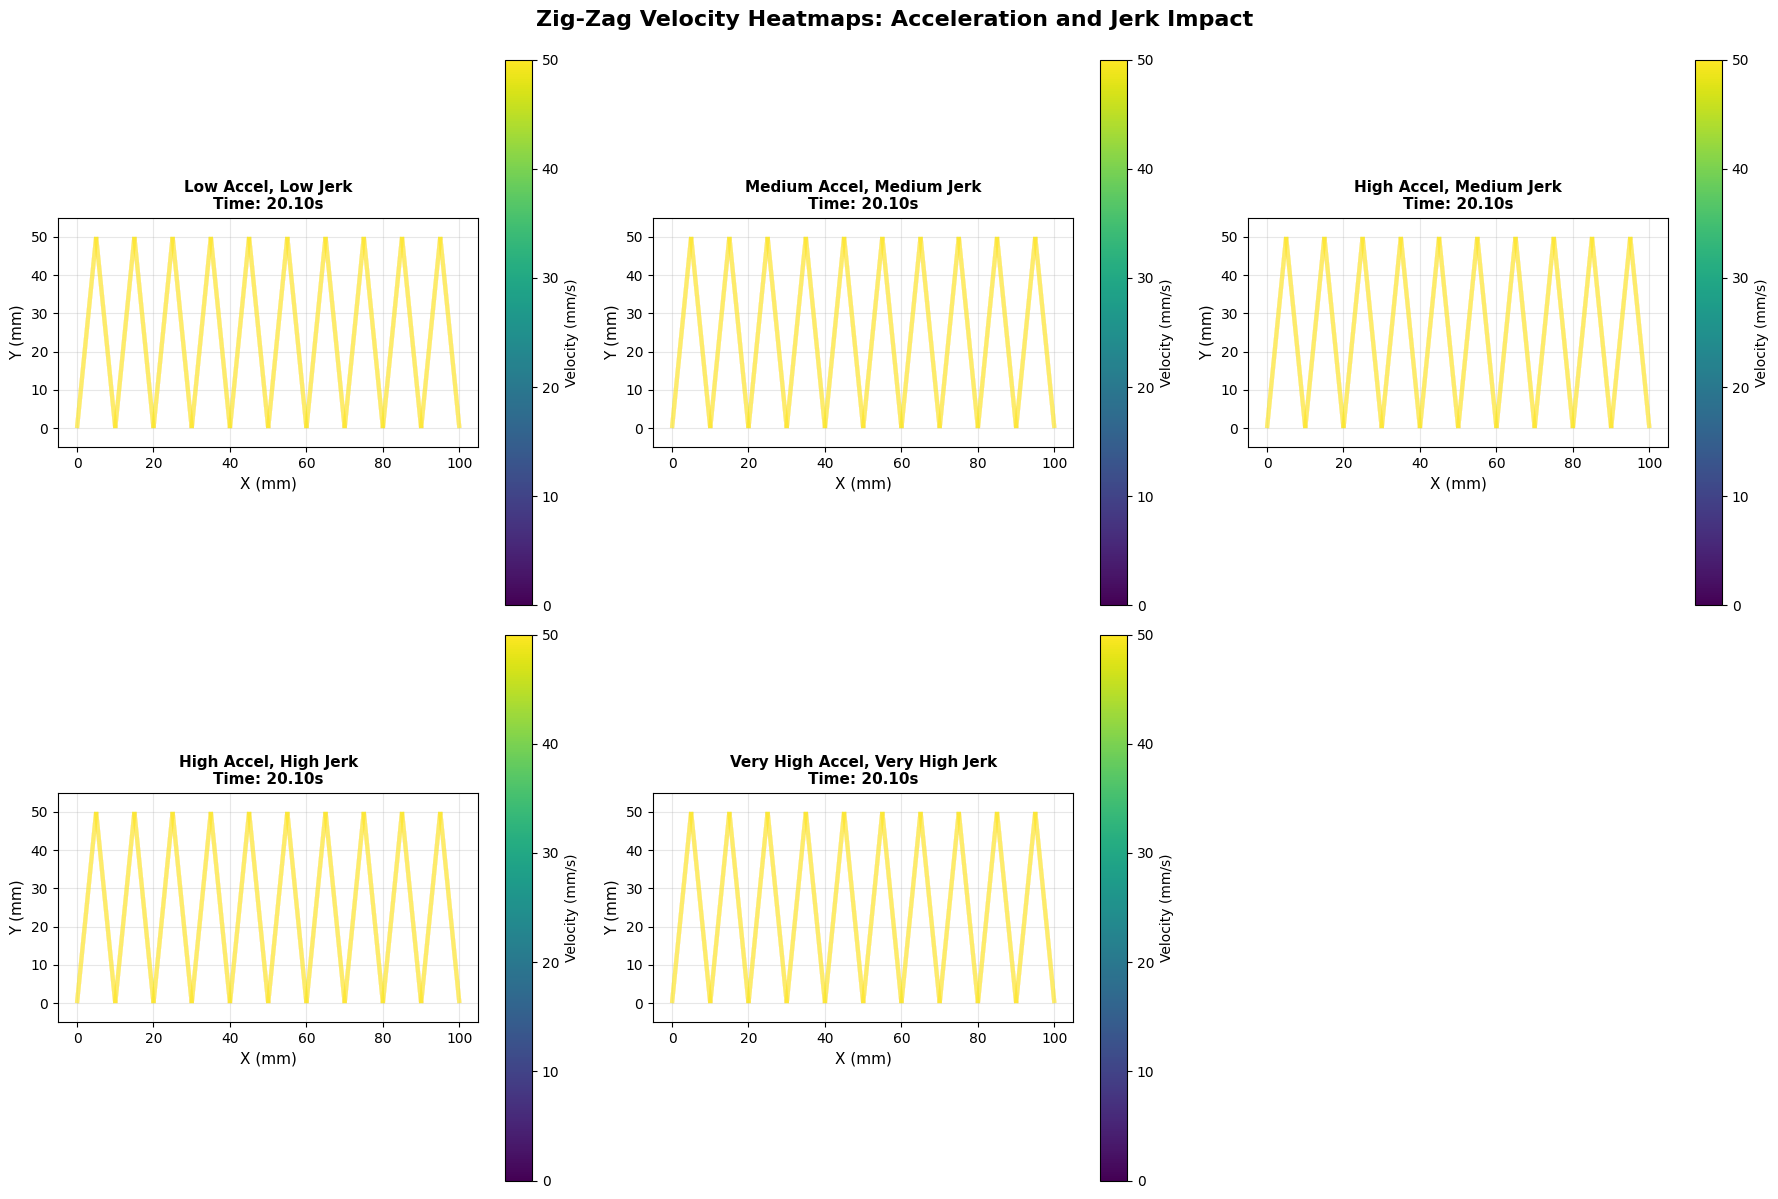

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, result in enumerate(results):
    if idx >= len(axes):
        break
        
    ax = axes[idx]
    traj = result['trajectory']
    x = traj[:, 1]
    y = traj[:, 2]
    vx, vy = traj[:, 4], traj[:, 5]
    v_mag = np.sqrt(vx**2 + vy**2)
    
    # Create segments for colored lines
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    from matplotlib.collections import LineCollection
    
    # Create line collection colored by velocity
    lc = LineCollection(segments, cmap='viridis', linewidth=3)
    lc.set_array(v_mag[:-1])
    lc.set_clim(0, np.max(v_mag))
    
    line = ax.add_collection(lc)
    
    # Add colorbar
    cbar = fig.colorbar(line, ax=ax)
    cbar.set_label('Velocity (mm/s)', fontsize=10)
    
    ax.set_xlim(x.min() - 5, x.max() + 5)
    ax.set_ylim(y.min() - 5, y.max() + 5)
    ax.set_xlabel('X (mm)', fontsize=11)
    ax.set_ylabel('Y (mm)', fontsize=11)
    ax.set_title(f"{result['name']}\nTime: {result['duration']:.2f}s", 
                 fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

# Hide unused subplots
for idx in range(len(results), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Zig-Zag Velocity Heatmaps: Acceleration and Jerk Impact', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('zigzag_velocity_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## Analysis: Performance Metrics Across Feed Rates

Test all configurations across multiple feed rates to find optimal settings.

In [48]:
import pandas as pd

all_metrics = []

for feed_rate in feed_rates:
    gcode = generate_zigzag_gcode(feedrate=feed_rate)
    
    for config in configs:
        trajectory, duration = process_zigzag(gcode, config['accel'], config['jerk'])
        
        vx, vy = trajectory[:, 4], trajectory[:, 5]
        ax, ay = trajectory[:, 7], trajectory[:, 8]
        v_mag = np.sqrt(vx**2 + vy**2)
        a_mag = np.sqrt(ax**2 + ay**2)
        
        all_metrics.append({
            'Configuration': config['name'],
            'Feed Rate (mm/min)': feed_rate,
            'Accel Limit (mm/s²)': config['accel'],
            'Jerk Limit (mm/s³)': config['jerk'],
            'Duration (s)': duration,
            'Avg Velocity (mm/s)': np.mean(v_mag),
            'Max Accel (mm/s²)': np.max(a_mag),
            'Accel RMS (mm/s²)': np.sqrt(np.mean(a_mag**2)),
        })

df_metrics = pd.DataFrame(all_metrics)

print("\n=== Performance Metrics Summary ===")
print(df_metrics.to_string(index=False))

df_metrics.to_csv('zigzag_performance_metrics.csv', index=False)
print("\nMetrics saved to: zigzag_performance_metrics.csv")


=== Performance Metrics Summary ===
                  Configuration  Feed Rate (mm/min)  Accel Limit (mm/s²)  Jerk Limit (mm/s³)  Duration (s)  Avg Velocity (mm/s)  Max Accel (mm/s²)  Accel RMS (mm/s²)
            Low Accel, Low Jerk                1000                  500                2000     30.594117            16.666394                0.0                0.0
      Medium Accel, Medium Jerk                1000                 1000                5000     30.594117            16.666394                0.0                0.0
        High Accel, Medium Jerk                1000                 2000                5000     30.594117            16.666394                0.0                0.0
          High Accel, High Jerk                1000                 2000               10000     30.594117            16.666394                0.0                0.0
Very High Accel, Very High Jerk                1000                 5000               20000     30.594117            16.666394      

## Visualization 4: Duration vs Configuration

See how cycle time varies with acceleration and feed rate settings.

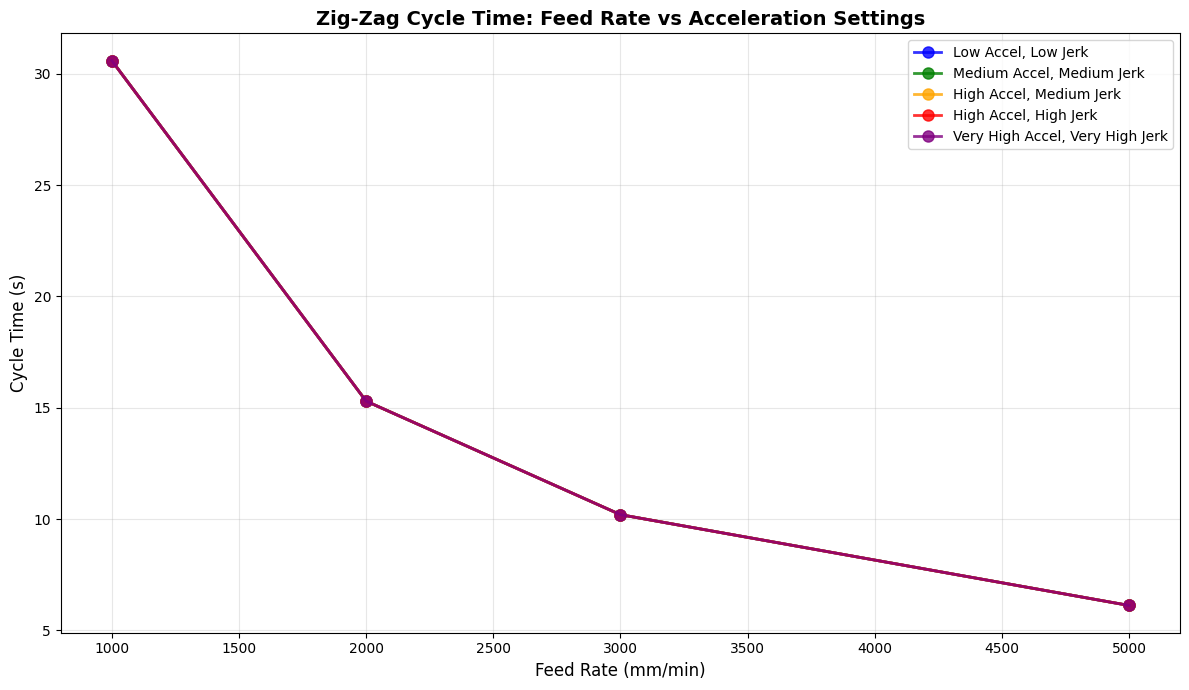

In [49]:
fig, ax = plt.subplots(figsize=(12, 7))

# Plot duration vs feed rate for each configuration
for config in configs:
    config_data = df_metrics[df_metrics['Configuration'] == config['name']]
    ax.plot(config_data['Feed Rate (mm/min)'], config_data['Duration (s)'],
            marker='o', linewidth=2, markersize=8, label=config['name'], 
            color=config['color'], alpha=0.8)

ax.set_xlabel('Feed Rate (mm/min)', fontsize=12)
ax.set_ylabel('Cycle Time (s)', fontsize=12)
ax.set_title('Zig-Zag Cycle Time: Feed Rate vs Acceleration Settings', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('zigzag_cycle_time_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3D Visualization: Feed Rate × Acceleration × Duration

Create a 3D surface plot showing the relationship between all parameters.

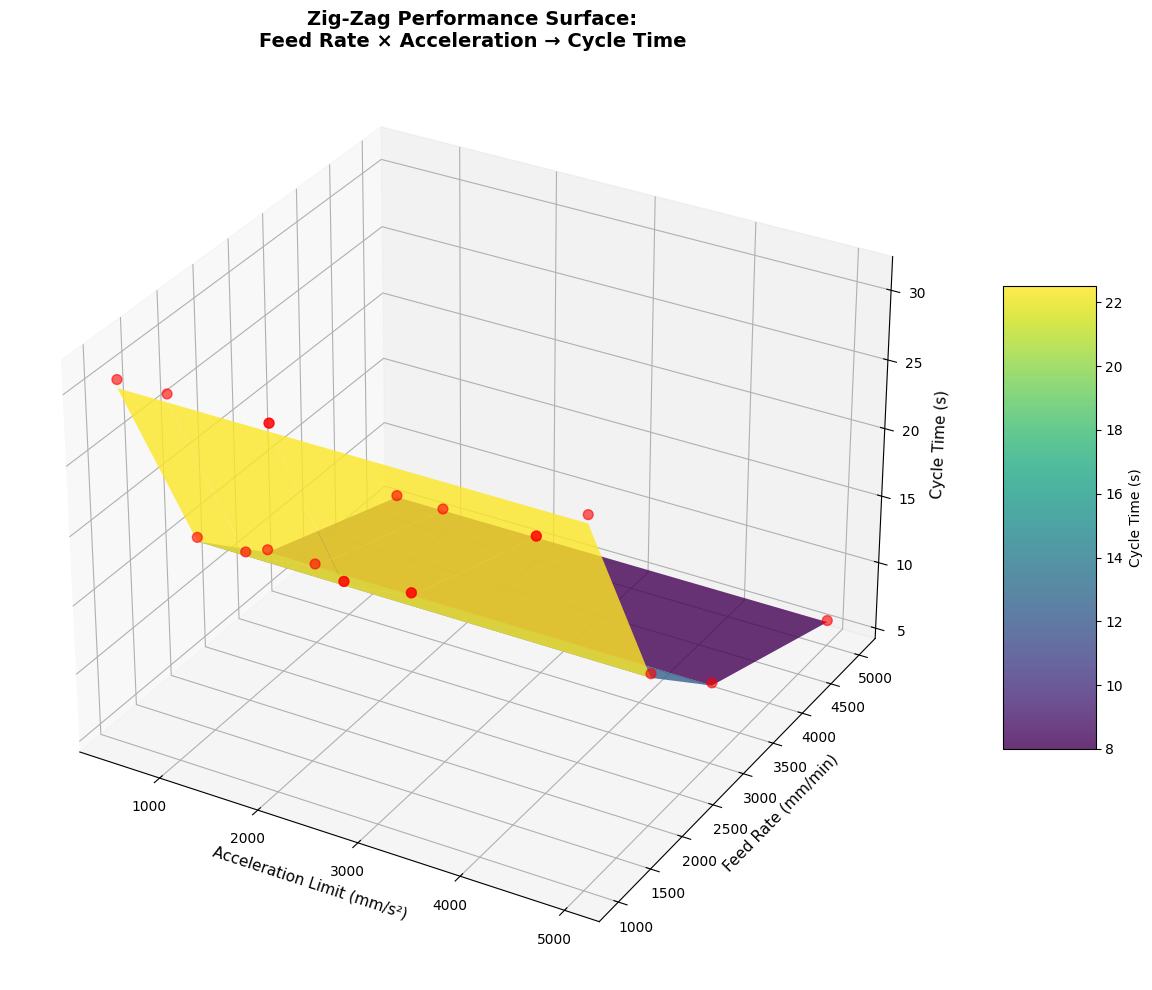

In [50]:
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Prepare data for surface plot
accel_values = sorted(df_metrics['Accel Limit (mm/s²)'].unique())
feed_values = sorted(df_metrics['Feed Rate (mm/min)'].unique())

# Create meshgrid
A, F = np.meshgrid(accel_values, feed_values)
D = np.zeros_like(A)

# Fill duration values
for i, feed in enumerate(feed_values):
    for j, accel in enumerate(accel_values):
        mask = (df_metrics['Feed Rate (mm/min)'] == feed) & \
               (df_metrics['Accel Limit (mm/s²)'] == accel)
        if mask.any():
            D[i, j] = df_metrics[mask]['Duration (s)'].values[0]

# Plot surface
surf = ax.plot_surface(A, F, D, cmap='viridis', alpha=0.8, edgecolor='none')

# Add scatter points
ax.scatter(df_metrics['Accel Limit (mm/s²)'], 
           df_metrics['Feed Rate (mm/min)'],
           df_metrics['Duration (s)'],
           c='red', marker='o', s=50, alpha=0.6)

ax.set_xlabel('Acceleration Limit (mm/s²)', fontsize=11)
ax.set_ylabel('Feed Rate (mm/min)', fontsize=11)
ax.set_zlabel('Cycle Time (s)', fontsize=11)
ax.set_title('Zig-Zag Performance Surface:\nFeed Rate × Acceleration → Cycle Time', 
             fontsize=14, fontweight='bold')

# Add colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Cycle Time (s)')

plt.tight_layout()
plt.savefig('zigzag_3d_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusions and Recommendations

### Key Findings:

1. **Acceleration Limits**:
   - Higher acceleration limits reduce cycle time but increase mechanical stress
   - Very high acceleration may cause oscillation and reduced accuracy
   - Diminishing returns beyond certain acceleration levels

2. **Jerk Limits**:
   - Jerk limiting smooths acceleration profiles
   - Reduces vibration and mechanical shock
   - Higher jerk limits allow faster acceleration changes

3. **Feed Rate Impact**:
   - Higher feed rates benefit more from high acceleration limits
   - At low feed rates, acceleration limits matter less
   - Corner geometry becomes limiting factor at high speeds

### Recommended Settings:

For typical machining applications:
- **Conservative**: Accel = 1000 mm/s², Jerk = 5000 mm/s³
- **Balanced**: Accel = 2000 mm/s², Jerk = 10000 mm/s³
- **Aggressive**: Accel = 5000 mm/s², Jerk = 20000 mm/s³

Always verify settings with your specific machine's capabilities and the workpiece requirements.